# Degree Bias in Graph Neural Networks
### A systematic investigation into why the node degree isn't the only factor for the misclassification of certain nodes (whether it may be mid- and high-degree nodes or just low-degree nodes but higher in count which is reported and perceived as the so-called "degree-bias")

---

This notebook presents the research problem, experimental setup, and structured investigation of degree bias in graph neural network node classification. Each section introduces a metric or structural property, motivates *why* it is relevant, and produces the corresponding analysis plot.

**Repository:** `DegBias`  
**Dataset:** Cora (citation network)  
**Models:** GCN (Kipf & Welling, 2017), GCNII (Chen et al., 2020)


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import copy
import yaml
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

from dataset import load_dataset
from dataset_utils import apply_split
from models import get_model
from train import train
from test import evaluate
from torch_geometric.utils import degree as graph_degree

from utils import (
    compute_distances_to_train, get_distance_deg,
    get_node_purity,
    get_labelling_ratio, get_avg_spl_to_train, get_avg_spl_to_same_class_train,
    get_training_neighbor_degree_stats,
    get_khop_cardinality,
)
from plot_utils import (
    get_accuracy_deg,
    plot_acc_vs_degree, plot_combined_vs_degree,
    plot_neighborhood_cardinality_vs_degree,
    plot_spl_vs_degree, plot_spl_combined_vs_degree, plot_labelling_ratio_vs_degree,
    plot_acc_and_labelling_ratio_vs_degree,
    plot_purity_vs_degree, plot_purity_delta_by_degree,
    plot_train_neighbor_degree_stats,
    plot_influence_analysis, plot_influence_per_neighbor,
)
from influence import compute_influence_analysis

print("Imports OK")


/home/luser/degree-bias-gnn/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


---
## 1. Research Problem

Graph Neural Networks (GNNs) for node classification are known to perform unevenly across nodes, but the structural reasons for this are not well understood. This project investigates **degree bias**: the hypothesis that a node's connectivity (its degree in the graph) systematically affects how well a GNN can classify it.

The investigation has revealed that **higher-degree nodes generally achieve higher accuracy** — consistent with the intuition that more connections bring richer aggregated signal. However, this is not always the case: **certain mid- and high-degree nodes are anomalously misclassified** despite the general trend. This motivates investigation into other graph and model properties to explain why degree alone does not fully determine performance.

### How this work goes beyond prior literature

| Aspect | Prior work | This repository |
|--------|-----------|-----------------|
| **Splits** | Public split only | Public + random splits |
| **Graph scope** | Full graph | Largest connected component only (removes trivially unreachable nodes) |
| **Degree grouping** | Coarse bins (low / high threshold) | Granular per-degree-value analysis |
| **Signal** | Accuracy trend only | Accuracy + structural metrics + model-behaviour (influence) |

The granular degree-wise analysis directly challenges the implicit assumption in prior work that *nodes with similar degree should have similar performance*. The anomalous misclassifications it surfaces are the central object of study.

### Central questions

1. What is the general relationship between node degree and classification accuracy, and where does it break down?
2. What structural properties of a node's neighbourhood explain anomalous misclassification among specific mid/high-degree nodes?
3. How does model depth (number of layers) interact with degree to affect accuracy?
4. Does the training signal that reaches a test node differ in quality for anomalously misclassified nodes?
5. Can the trained model's internal influence distribution explain misclassification at certain degree groups?


---
## 2. Experimental Setup

### 2.1 Dataset — Cora

| Property | Value |
|---|---|
| Nodes | ~2,708 |
| Edges | ~5,429 (undirected) |
| Node features | 1,433-dimensional bag-of-words |
| Classes | 7 (paper topics) |
| Task | Semi-supervised node classification |

Cora is a citation network: nodes are papers and edges are citations. Each node's feature vector is a binary bag-of-words over a fixed vocabulary. The task is to classify each paper into one of 7 topic categories, using a small labelled set (≈140 nodes) and message passing over the full graph.

### 2.2 Connected Component Filtering (`use_cc: true`)

Only the **largest connected component** is kept. Cora contains a small number of isolated nodes and tiny disconnected components. These are excluded because:
- GNNs propagate information through edges — nodes in disconnected components can never receive training signal.
- Including them would conflate **degree bias** (the research object) with a trivially different problem: complete absence of training signal due to structural disconnection.
- By working on the CC only, every node can, in principle, receive signal from training nodes via message passing. Misclassifications are thus attributable to aggregation dynamics, not connectivity failures.

This filtering step is **not consistently applied in prior literature**, making comparisons with our results non-trivial.

### 2.3 Data Splits

| Split | Train | Val | Test |
|---|---|---|---|
| `public` | 20/class = 140 | 500 | 1,000 |
| `random` | 20/class = 140 (drawn randomly) | 500 | 1,000 |

For a **random split**, the partition is fixed at `base_seed=42` so all 5 runs share the same train/val/test nodes — only model initialisation varies. The random split enables testing whether degree-bias findings are structural properties of the graph or artefacts of which specific nodes happen to be labelled.

### 2.4 Models

**GCN** (Kipf & Welling, 2017)
- Architecture: `num_layers - 1` GCNConv layers + 1 `nn.Linear(hidden_dim, out_dim)` classification head
- Receptive field: `num_layers - 1` hops (the final layer is a linear head with no message passing)
- Each layer: $H^{(l+1)} = \sigma(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2} H^{(l)} W^{(l)})$
- Aggregation weight for edge $(u \to v)$: $1/\sqrt{\deg(u) \cdot \deg(v)}$ — high-degree nodes get diluted

**GCNII** (Chen et al., 2020)
- Adds initial residual connections and identity mapping per layer
- Allows very deep networks (64+ layers) without over-smoothing
- Used here as a contrastive baseline: does mitigating over-smoothing also mitigate degree bias?

### 2.5 Hyperparameters

| Parameter | GCN | GCNII |
|---|---|---|
| Hidden dim | 512 | 64 |
| Num layers | 2 | 64 |
| Dropout | 0.0 | 0.5 |
| LR | 0.001 | 0.01 |
| Weight decay | 5e-4 | 5e-4 |
| Epochs | 200 | 200 |
| Early stopping | patience=50 | patience=100 |
| Runs | 5 | 5 |


In [2]:
import copy, random, os
import yaml
import torch
import numpy as np
from torch_geometric.utils import degree as graph_degree

from dataset import load_dataset
from dataset_utils import apply_split
from models import get_model
from train import train
from test import evaluate
from utils import (
    compute_distances_to_train, get_distance_deg,
    get_node_purity,
    get_labelling_ratio, get_avg_spl_to_train, get_avg_spl_to_same_class_train,
    get_training_neighbor_degree_stats,
    get_khop_cardinality,
)
from plot_utils import get_accuracy_deg

# ── helpers ──────────────────────────────────────────────────────────────────

def _deep_merge(base, override):
    merged = copy.deepcopy(base)
    for key, val in override.items():
        if key in merged and isinstance(merged[key], dict) and isinstance(val, dict):
            merged[key] = _deep_merge(merged[key], val)
        else:
            merged[key] = copy.deepcopy(val)
    return merged

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# ── load config ───────────────────────────────────────────────────────────────
with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

model_name   = cfg['model']['name']
dataset_name = cfg['dataset']['name']
model_cfg_path = os.path.join('configs', f'{model_name}_{dataset_name}.yaml')
if os.path.exists(model_cfg_path):
    with open(model_cfg_path) as f:
        cfg = _deep_merge(cfg, yaml.safe_load(f))
    print(f'Loaded model config: {model_cfg_path}')

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_seed  = cfg.get('seed', 42)
num_runs   = cfg.get('num_runs', 5)
split      = cfg.get('split', 'public')
plot_cfg   = cfg.get('plot', {})
k_hops     = cfg['model']['num_layers'] - 1   # receptive field depth (no message passing in final Linear)
purity_k_max = plot_cfg.get('purity_k_max', 2)

print(f'Dataset: {dataset_name} | Model: {model_name} | num_layers: {cfg["model"]["num_layers"]} | k_hops: {k_hops} | split: {split} | device: {device}')

# ── load dataset + split ──────────────────────────────────────────────────────
data = load_dataset(cfg['dataset'])
if split == 'random':
    set_seed(base_seed)
data = apply_split(data, split, cfg['dataset'])
data = data.to(device)

print(f'Nodes: {data.num_nodes} | Edges: {data.edge_index.shape[1]//2} | Features: {data.num_node_features} | Classes: {int(data.y.max().item())+1}')
print(f'Train: {data.train_mask.sum().item()} | Val: {data.val_mask.sum().item()} | Test: {data.test_mask.sum().item()}')

# ── graph-fixed quantities (computed once) ────────────────────────────────────
all_deg  = graph_degree(data.edge_index[1], data.num_nodes).cpu()
test_deg = all_deg[data.test_mask.cpu()]

has_labeled_neighbor = get_labelling_ratio(data)[data.test_mask.cpu()]
avg_spl              = get_avg_spl_to_train(data)[data.test_mask.cpu()]
avg_spl_same_class   = get_avg_spl_to_same_class_train(data)[data.test_mask.cpu()]

dist_to_train, dist_to_same_class = compute_distances_to_train(data)
dist_deg_data = get_distance_deg(test_deg, dist_to_train, dist_to_same_class, num_nodes=data.num_nodes)


purity_by_k = {k: get_node_purity(data, k=k) for k in range(1, purity_k_max + 1)}

train_nb_deg_stats = get_training_neighbor_degree_stats(data, k=k_hops)

# k=1 and k=2 neighbourhood cardinality per test node (graph-fixed)
cardinality_by_k = {k: get_khop_cardinality(data, k)[data.test_mask].cpu() for k in [1, 2]}

print('All graph-fixed quantities computed.')


Loaded model config: configs/GCN_Cora.yaml
Dataset: Cora | Model: GCN | num_layers: 3 | k_hops: 2 | split: public | device: cuda
Nodes: 2485 | Edges: 5069 | Features: 1433 | Classes: 7
Train: 122 | Val: 459 | Test: 915
All graph-fixed quantities computed.


---
## 3. Training

Train the model for `num_runs` seeds. All runs share the same data split; only model initialisation varies. We collect per-run degree-wise accuracy for boxplot distributions.


In [3]:
def run_once(data, cfg, seed, device):
    """Train one model, return (val_acc, test_acc, train_acc, loss, pred, model)."""
    model_cfg = cfg['model']
    num_classes = int(data.y.max().item()) + 1
    model = get_model(
        model_cfg['name'],
        in_dim=data.num_node_features,
        hidden_dim=model_cfg['hidden_dim'],
        out_dim=num_classes,
        num_layers=model_cfg['num_layers'],
        dropout=model_cfg['dropout'],
    ).to(device)

    train_cfg = cfg['train']
    optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg['lr'],
                                 weight_decay=float(train_cfg['weight_decay']))
    criterion = torch.nn.CrossEntropyLoss()

    best_val, best_test, best_train, best_loss = 0.0, 0.0, 0.0, float('nan')
    best_state = copy.deepcopy(model.state_dict())
    patience_counter, patience = 0, train_cfg.get('patience', 0)

    for epoch in range(1, train_cfg['epochs'] + 1):
        loss = train(model, data, optimizer, criterion)
        results = evaluate(model, data)
        if results['val'] > best_val:
            best_val, best_test, best_train, best_loss = (
                results['val'], results['test'], results['train'], loss)
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        if patience > 0 and patience_counter >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index).argmax(dim=1)
    return best_val, best_test, best_train, best_loss, pred, model

# ── run loop ──────────────────────────────────────────────────────────────────
val_accs, test_accs, train_accs = [], [], []
deg_acc_results = []
final_pred, final_model = None, None

for i in range(1, num_runs + 1):
    seed = base_seed + i - 1
    set_seed(seed)
    print(f'Run {i}/{num_runs}  seed={seed}', end='  ')
    val_acc, test_acc, train_acc, loss, pred, model = run_once(data, cfg, seed, device)
    val_accs.append(val_acc)
    test_accs.append(test_acc)
    train_accs.append(train_acc)
    print(f'train={train_acc:.4f}  val={val_acc:.4f}  test={test_acc:.4f}')
    deg_acc_results.append(get_accuracy_deg(test_deg, pred[data.test_mask], data.y[data.test_mask]))
    final_pred, final_model = pred, model   # keep last run for influence analysis

print(f'\nSummary over {num_runs} runs:')
print(f'  Train: {np.mean(train_accs):.4f} ± {np.std(train_accs):.4f}')
print(f'  Val:   {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}')
print(f'  Test:  {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}')
print(f'\nModel architecture:\n{model}')


Run 1/5  seed=42  train=0.9857  val=0.8280  test=0.8142
Run 2/5  seed=43  train=1.0000  val=0.8300  test=0.8077
Run 3/5  seed=44  train=0.9786  val=0.8380  test=0.7978
Run 4/5  seed=45  train=1.0000  val=0.8320  test=0.8077
Run 5/5  seed=46  train=1.0000  val=0.8220  test=0.8000

Summary over 5 runs:
  Train: 0.9929 ± 0.0090
  Val:   0.8300 ± 0.0052
  Test:  0.8055 ± 0.0059

Model architecture:
GCN(
  (layers): ModuleList(
    (0): GCNConv(1433, 512)
    (1): GCNConv(512, 512)
    (2): Linear(in_features=512, out_features=7, bias=True)
  )
)


---
## 4. Investigation

### 4.1 Accuracy vs Node Degree

**Why this matters:**
The first and most fundamental question is whether degree predicts accuracy at all. Prior work typically answers this with a coarse split (low-degree vs high-degree threshold). Here we examine accuracy **at each individual degree value** — a granular view that reveals whether the trend is clean or contains outliers.

The **expected finding** (and what we observe) is that accuracy generally *increases* with degree: more connections bring richer aggregated signal from the neighbourhood. However, the interesting part is not the trend itself but the **anomalies** — specific mid- and high-degree nodes that are misclassified despite this general advantage. These anomalies cannot be seen with coarse binning, which is precisely why we use this granular approach.

The node-count panel (bottom) is critical context: conclusions about high-degree groups are only meaningful if they are backed by a sufficient number of test nodes.


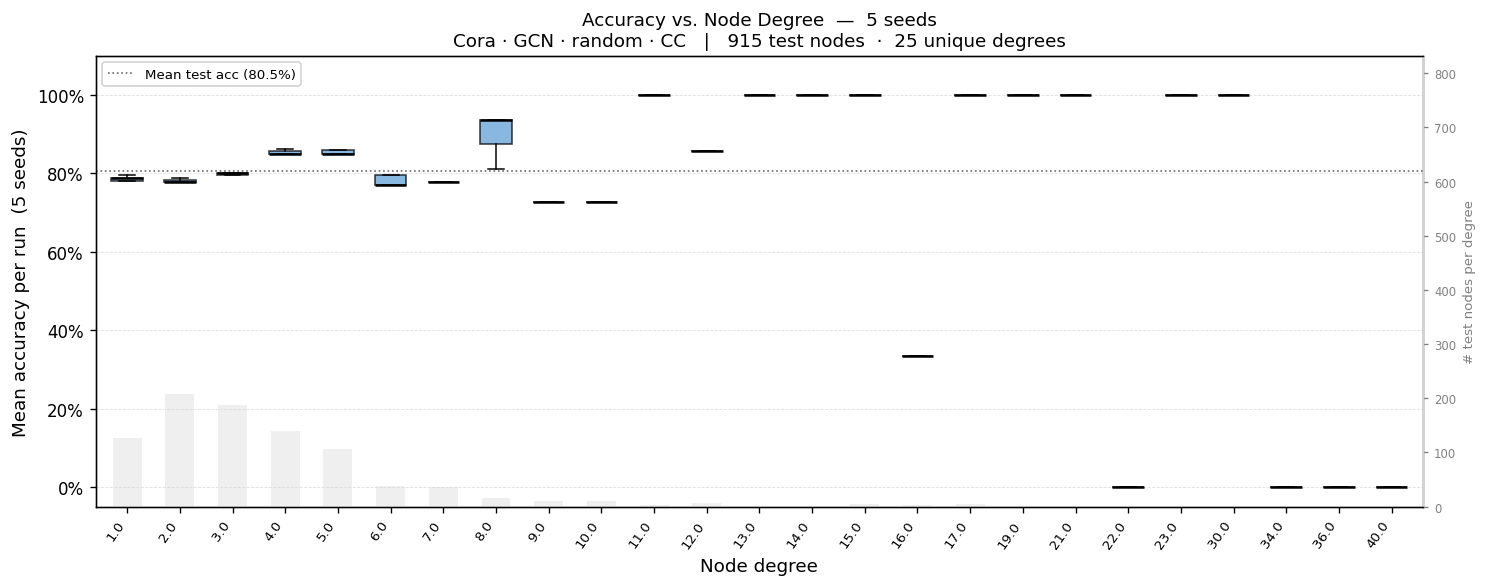

In [ ]:
from plot_utils import plot_acc_vs_degree

plot_acc_vs_degree(
    deg_acc_results,
    cfg,
    save_dir=None,
    show=True,
)


---
### 4.2 Neighbourhood Cardinality vs Degree

**Why this matters:**
A node's 1-hop degree tells us how many direct neighbours it has. But a GNN's message-passing aggregates information from the full k-hop receptive field — the set of all nodes reachable within k hops. Two test nodes with identical 1-hop degree can have very different k=2 neighbourhood sizes: one might sit at the edge of a sparse region, the other at the centre of a dense cluster.

This plot asks: **how does neighbourhood size grow from k=1 to k=2 as a function of 1-hop degree?** It reveals:

- **Cardinality expansion:** for high-degree nodes, the 2-hop neighbourhood can be an order of magnitude larger than the 1-hop neighbourhood — these nodes aggregate information from potentially hundreds of upstream nodes, not just their direct neighbours.
- **Variance within degree groups:** nodes with the same 1-hop degree can have very different 2-hop neighbourhood sizes (shown by the ±1 std shading), meaning the k=1 degree label is a coarse proxy for actual receptive-field richness.
- **Relationship to accuracy:** the accuracy overlay shows whether nodes sitting in larger k=2 neighbourhoods (richer aggregation context) tend to be classified more accurately — and where the trend breaks down for anomalously misclassified nodes.

Note that the k=1 line is by definition equal to the degree value (std = 0 within each degree group, since the grouping *is* the 1-hop degree). It serves as a reference to show the multiplicative expansion factor from k=1 to k=2.

A **delta purity** panel (bottom) is added to complement the structural picture. Delta purity = `purity(k=2) − purity(k=1)` for each node — how much the class homogeneity of the neighbourhood degrades when the receptive field expands by one hop. It is negative by construction (more neighbours → more cross-class mixing), and the magnitude reveals which degree groups lose the most signal quality as the GNN looks deeper. By sharing the x-axis with the cardinality panel above, the reader can directly ask: *for degree groups where the 2-hop neighbourhood explodes in size, does the purity also degrade steeply?* This links the quantity of aggregated information (top panel) to its quality (bottom panel).

**Anomaly highlights (★ markers + dashed crimson vertical lines):** Degree groups where all three structural signals align simultaneously are automatically flagged:
- Accuracy **below** the cross-degree median (model fails here)
- k=2 cardinality **above** the cross-degree mean (neighbourhood explodes)
- Δ purity **more negative** than the cross-degree mean (signal degrades)

The dashed vertical line spans both panels so the reader can trace the same degree value from the cardinality explosion (top) down to the purity degradation (bottom) and read off the accuracy penalty at that degree. Degree labels are printed at the top of the upper panel. Up to five anomalies are shown (sorted by accuracy, worst first); groups with fewer than 3 test nodes are excluded to suppress single-node noise.


k=1 cardinality range: 1 – 40
k=2 cardinality range: 2 – 287


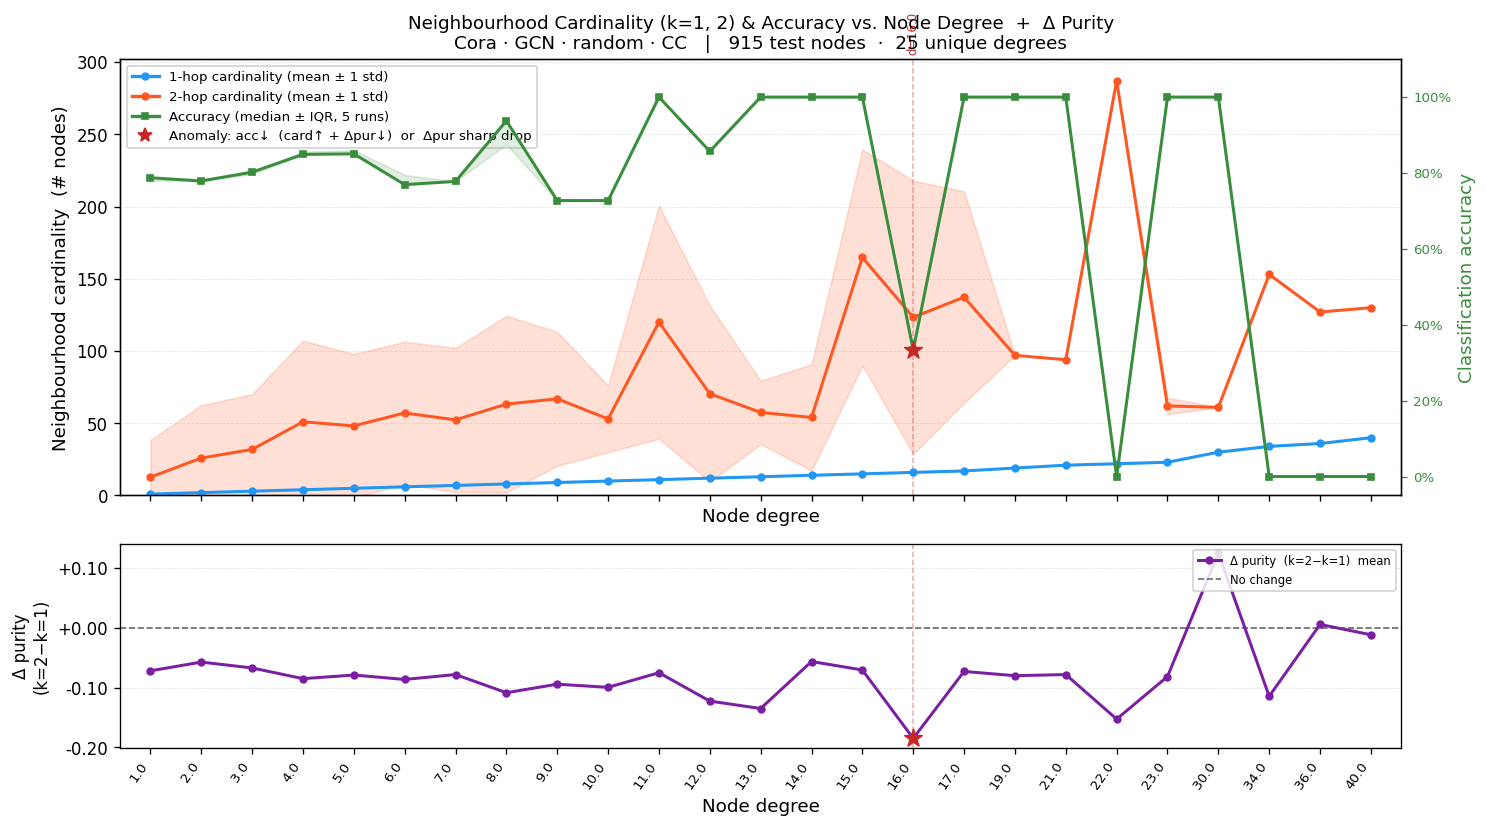

In [5]:
from plot_utils import plot_neighborhood_cardinality_vs_degree

print(f"k=1 cardinality range: {cardinality_by_k[1].min().item()} – {cardinality_by_k[1].max().item()}")
print(f"k=2 cardinality range: {cardinality_by_k[2].min().item()} – {cardinality_by_k[2].max().item()}")

plot_neighborhood_cardinality_vs_degree(
    test_deg,
    cardinality_by_k,
    deg_acc_results,
    cfg,
    all_deg=all_deg,
    purity_by_k=purity_by_k,   # enables delta-purity bottom panel
    save_dir=None,
    show=True,
)


---
### 4.3 Layer-wise Comparison — How Depth Interacts with Degree

**Why this matters:**
A GNN with more layers expands its receptive field by one hop per layer. For a GCN with `num_layers = L`, there are `L-1` GCNConv layers and 1 final linear head, so the receptive field is `L-1` hops. Adding layers has two competing effects:

- **Benefit:** more hops = more training nodes potentially reachable = richer aggregated signal.
- **Cost:** more hops = the receptive field grows (potentially explosively for high-degree nodes), pulling in more cross-class signal and causing **over-smoothing** as all node representations converge.

The layer sweep tests which effect dominates, and — critically — whether the answer differs by degree:

- **Low-degree nodes** have small receptive fields at any depth. More layers may genuinely help by extending their reach to distant same-class training nodes.
- **High-degree nodes** already have large 1-hop and 2-hop neighbourhoods. More layers could make their over-smoothing problem worse, as the 3-hop and 4-hop neighbourhoods are enormous and highly heterogeneous.

The **trend plot** (slope of accuracy vs layer count per degree group) directly answers: for which degree groups does adding depth help vs hurt? A negative slope for high-degree nodes while a positive slope for low-degree nodes would confirm that depth trades off differently across the degree spectrum.

The layer values swept here are `[1, 2, 3, 4, 5]` corresponding to `[0, 1, 2, 3, 4]` GCNConv layers respectively (the last layer is always a linear head with no message passing).


Layer sweep: [2, 3, 4, 5, 6]  (GCNConv layers = [L-1 for L in layer_values])
Training GCN L=1...  
  Architecture: GCN(
  (layers): ModuleList(
    (0): GCNConv(1433, 512)
    (1): Linear(in_features=512, out_features=7, bias=True)
  )
)
Training GCN L=2...  done
Training GCN L=3...  done
Training GCN L=4...  done
Training GCN L=5...  done

Plotting...


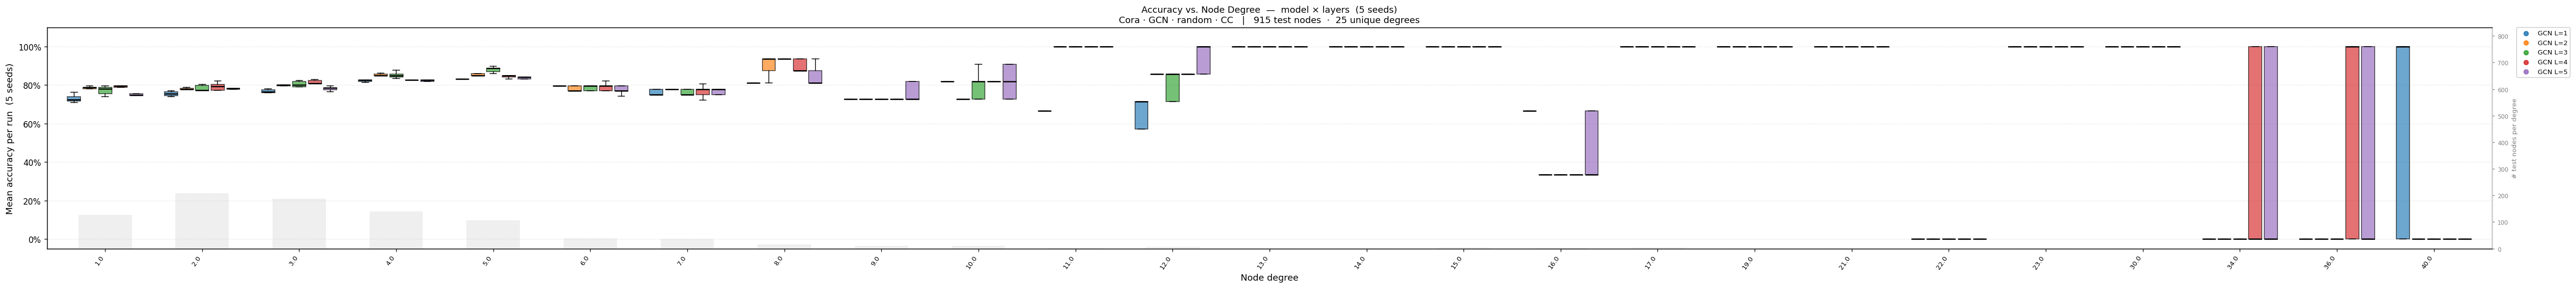

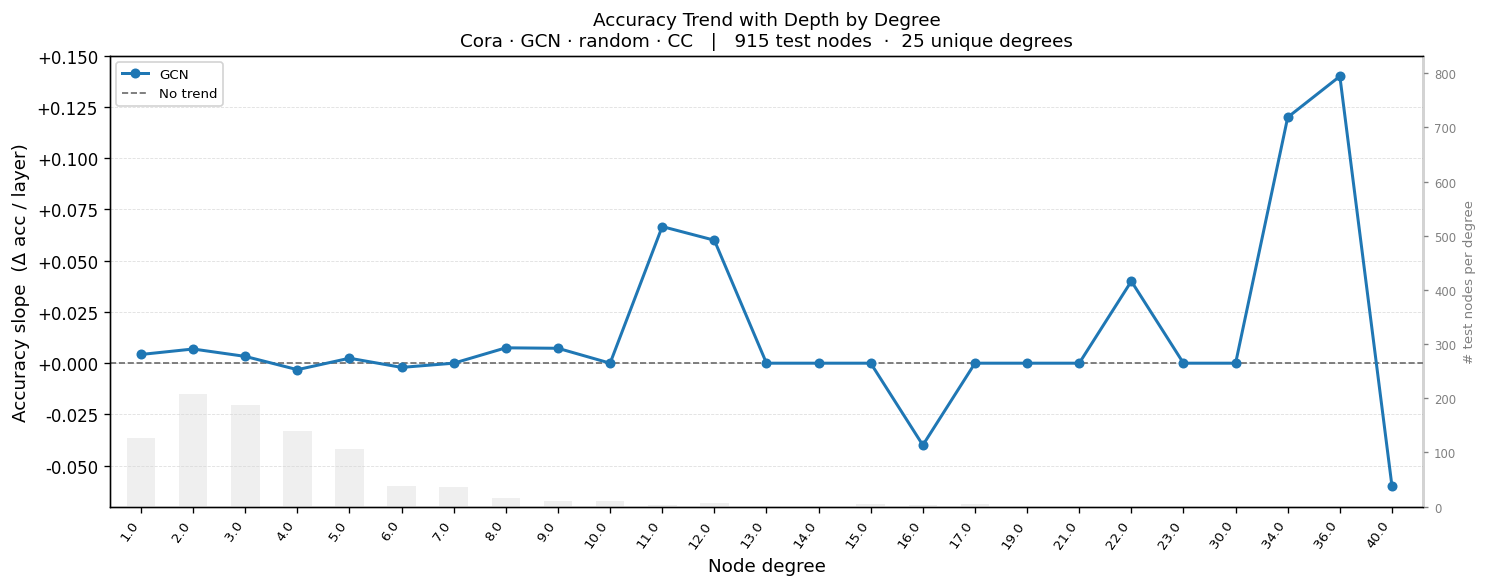

In [6]:
from plot_utils import plot_acc_vs_degree_by_layers, plot_acc_trend_by_degree

layer_values = cfg['plot'].get('layer_values', [1, 2, 3, 4, 5])
print(f'Layer sweep: {layer_values}  (GCNConv layers = [L-1 for L in layer_values])')

results_by_label = {}
for L in layer_values:
    label = f"GCN L={L - 1}"
    print(f'Training {label}...', end='  ')
    run_cfg = copy.deepcopy(cfg)
    run_cfg['model']['num_layers'] = L
    label_results = []
    for i in range(1, num_runs + 1):
        set_seed(base_seed + i - 1)
        _, _, _, _, pred_L, model_L = run_once(data, run_cfg, base_seed + i - 1, device)
        label_results.append(
            get_accuracy_deg(test_deg, pred_L[data.test_mask], data.y[data.test_mask])
        )
    results_by_label[label] = label_results
    if L == layer_values[0]:
        print(f'\n  Architecture: {model_L}')
    else:
        print('done')

print('\nPlotting...')

# Per-degree boxplot grouped by layer count
plot_acc_vs_degree_by_layers(
    results_by_label, cfg,
    save_dir=None, show=True,
)

# Slope of accuracy vs layer count per degree group
plot_acc_trend_by_degree(
    results_by_label, cfg,
    save_dir=None, show=True,
)


---
### 4.4 Distance to Training Nodes

**Why this matters:**
GNNs can only propagate information from labelled nodes through edges. A test node that is structurally far from training nodes receives heavily diluted label signal — each additional hop averages over another node's full neighbourhood, mixing in more cross-class content.

We compute two distance variants for each test node:
- `dist_to_train`: minimum hops to reach *any* training node
- `dist_to_same_class_train`: minimum hops to reach a training node of the *same class*

The key insight is in the **difference between the two**: a test node with `dist_to_train = 1` (a labelled neighbour exists) but `dist_to_same_class_train = 3` (the nearest same-class label is 3 hops away) is in a locally hostile neighbourhood — it has a labelled neighbour, but that neighbour is of the wrong class. For high-degree nodes, more edges mean more paths to training nodes, but also more paths to *wrong-class* training nodes, making `dist_to_same_class_train` more variable and often longer than expected.


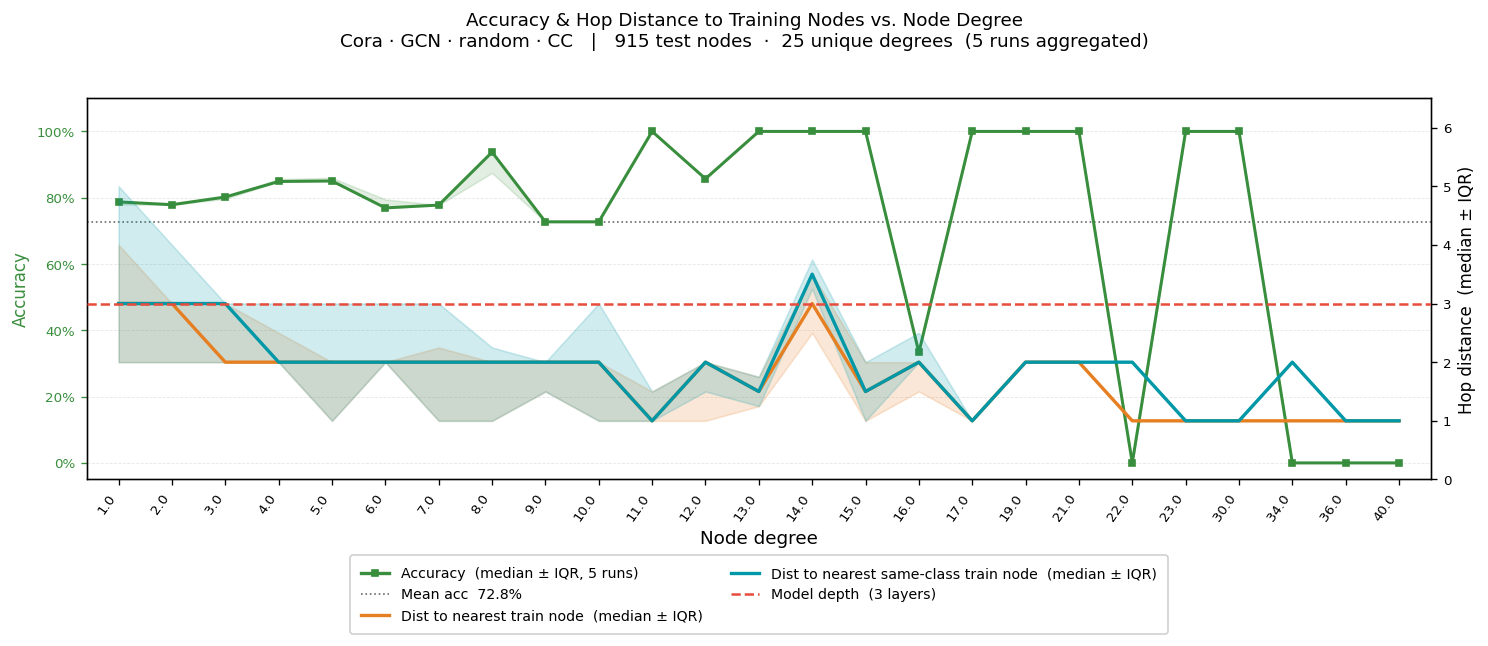

In [7]:
from plot_utils import plot_combined_vs_degree

plot_combined_vs_degree(
    deg_acc_results,
    dist_deg_data,
    cfg,
    save_dir=None,
    show=True,
)


---
### 4.5 Average Shortest Path Length (SPL) to Training Nodes

**Why this matters:**
The minimum distance to training nodes (§4.3) is a binary threshold: it tells us if at least one path exists. But a test node might have **one** nearby training node and be structurally far from all others — it receives strong signal from a tiny fraction of the training set.

**Average SPL** gives a richer picture of training-signal coverage:
- **SPL to all training nodes:** does the test node sit in a region that is well-connected to the labelled set overall?
- **SPL to same-class training nodes:** how far is the test node from label signal of its own class, on average?

If high-degree nodes tend to have longer average SPL to same-class training nodes (even when they are close to some training node), that indicates a **class-specific signal quality problem**: the label signal arriving at the node is dominated by training nodes of the wrong class. This is distinct from the structural neighbourhood composition problem (purity) — here we are measuring the *label accessibility* aspect of the training data distribution.


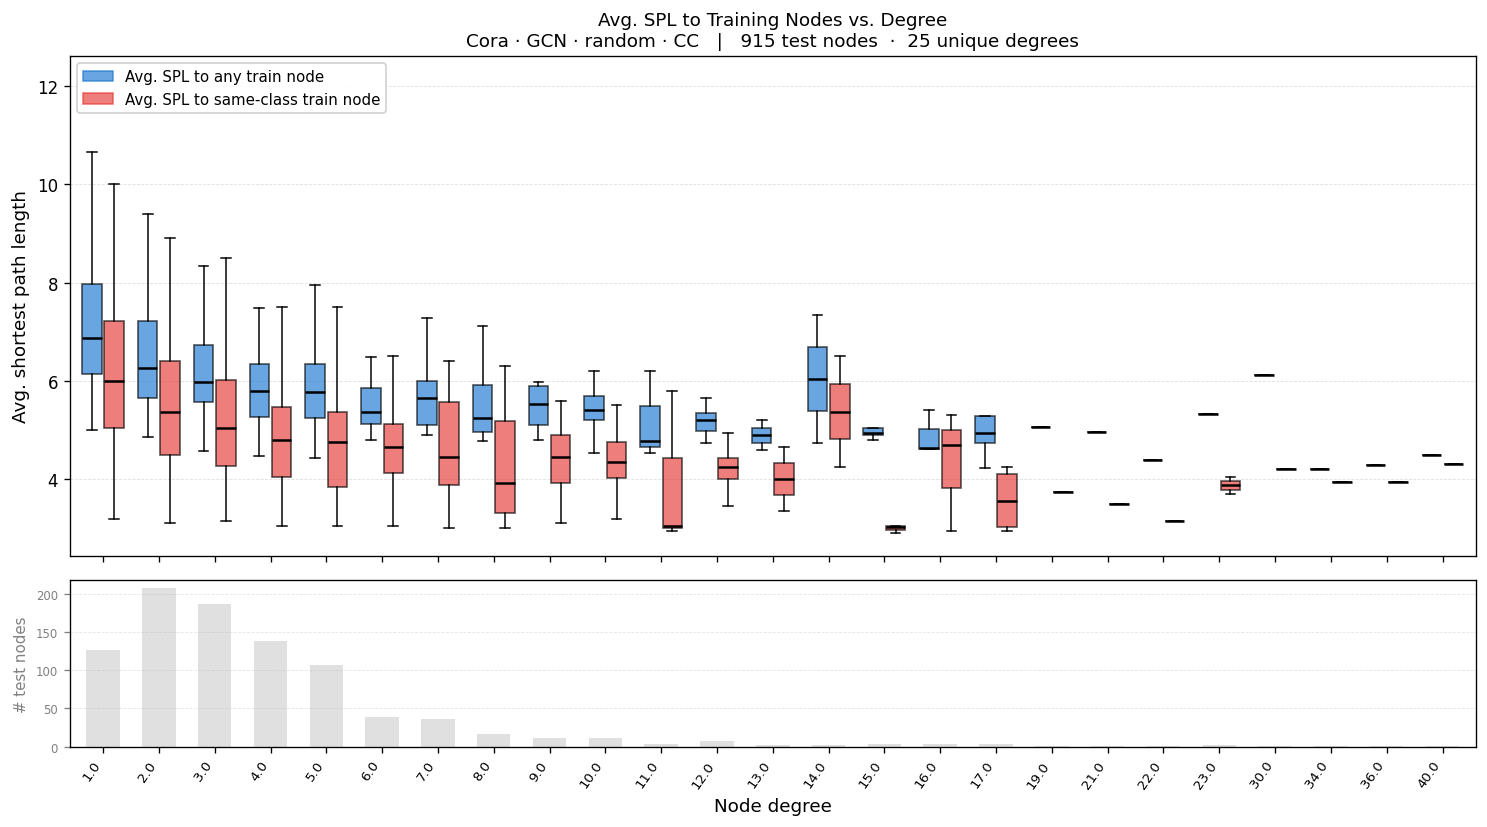

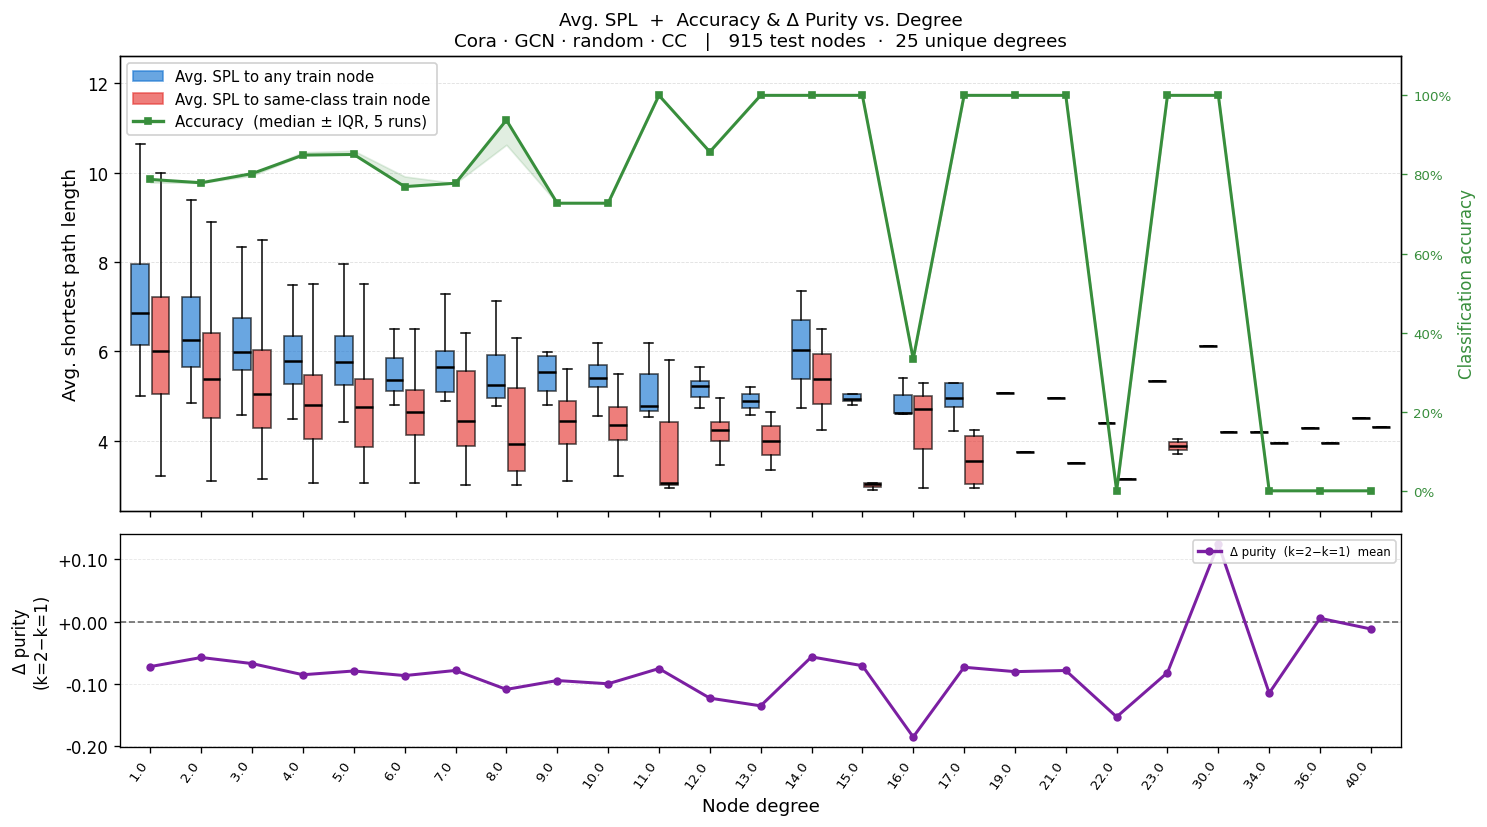

In [8]:
from plot_utils import plot_spl_combined_vs_degree

plot_spl_combined_vs_degree(
    test_deg, avg_spl, avg_spl_same_class, cfg,
    deg_acc_results=deg_acc_results,
    purity_by_k=purity_by_k,
    all_deg=all_deg,
    save_dir=None, show=True,
)


---
### 4.6 Labelling Ratio

**Why this matters:**
A test node with a labelled **immediate** (1-hop) neighbour receives direct, undiluted label signal in the first GNN layer — the training node's features are aggregated directly into the test node's representation before any further mixing. Nodes without any labelled direct neighbour must rely entirely on **indirect** signal that has already been diluted through one or more intermediate (non-training) nodes.

The labelling ratio is a binary indicator: does a test node have ≥1 training node as a direct neighbour?

Plotting this against accuracy (twin-axis) reveals whether first-hop label availability **co-varies** with correct classification. If the fraction of labelled neighbours drops for certain degree groups and accuracy dips at the same degree groups, that is strong evidence that **first-hop label proximity** is a meaningful driver of performance — not just general connectivity.


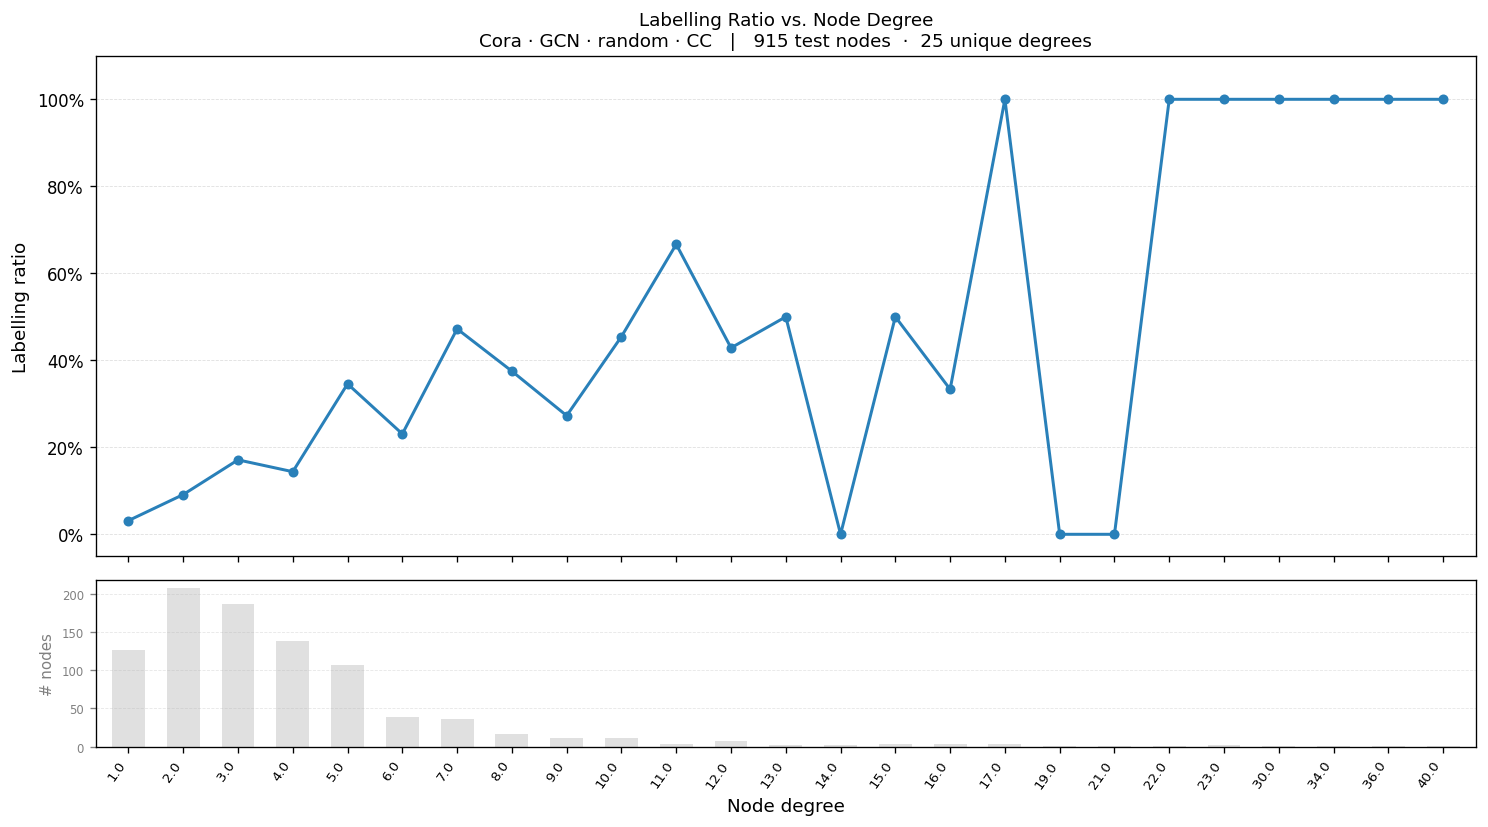

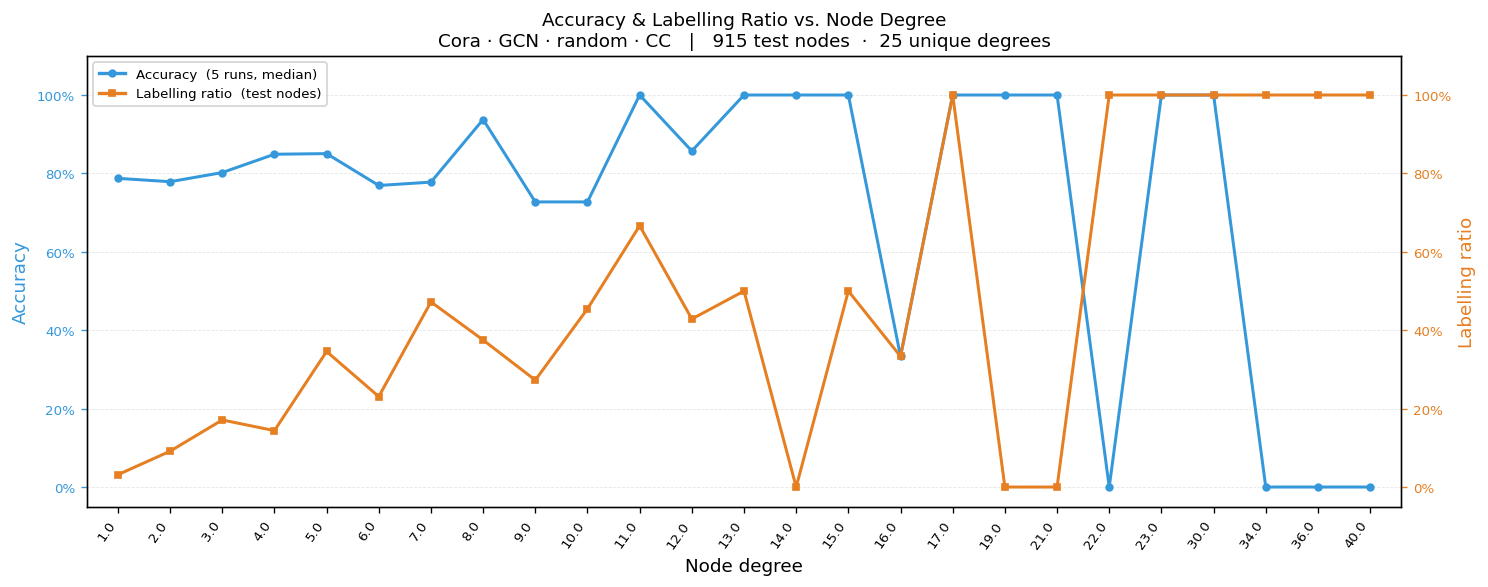

In [9]:
from plot_utils import plot_labelling_ratio_vs_degree, plot_acc_and_labelling_ratio_vs_degree

# Labelling ratio by degree (standalone)
plot_labelling_ratio_vs_degree(
    test_deg, has_labeled_neighbor, cfg,
    save_dir=None, show=True,
)

# Accuracy + labelling ratio overlaid on twin axes
plot_acc_and_labelling_ratio_vs_degree(
    deg_acc_results, test_deg, has_labeled_neighbor, cfg,
    save_dir=None, show=True,
)


---
### 4.7 Neighbourhood Purity

**Why this matters:**
Even if a test node has labelled neighbours, those neighbours may be of a **different class**, injecting misleading signal. Neighbourhood purity measures the class composition of the k-hop neighbourhood:

$$\text{purity}_k(v) = \frac{|\{u \in N_k(v) : \text{label}[u] = \text{label}[v]\}|}{|N_k(v)|}$$

High purity means the neighbourhood is mostly same-class — the aggregated message reinforces the correct classification. Low purity (high class heterogeneity) means the aggregated message is noisy, with cross-class information potentially drowning out the class-discriminative signal.

For Cora — a citation network where papers cite across topic boundaries — high-degree nodes tend to be **hubs spanning multiple research communities**. Their k-hop neighbourhoods therefore contain a wider cross-section of classes, making purity naturally lower.

**Delta purity** (`purity(k=2) − purity(k=1)`) captures how much purity *degrades* as the neighbourhood expands. A steep negative delta predicts that adding more GNN layers will hurt those nodes — their widening receptive field samples progressively noisier class signal.


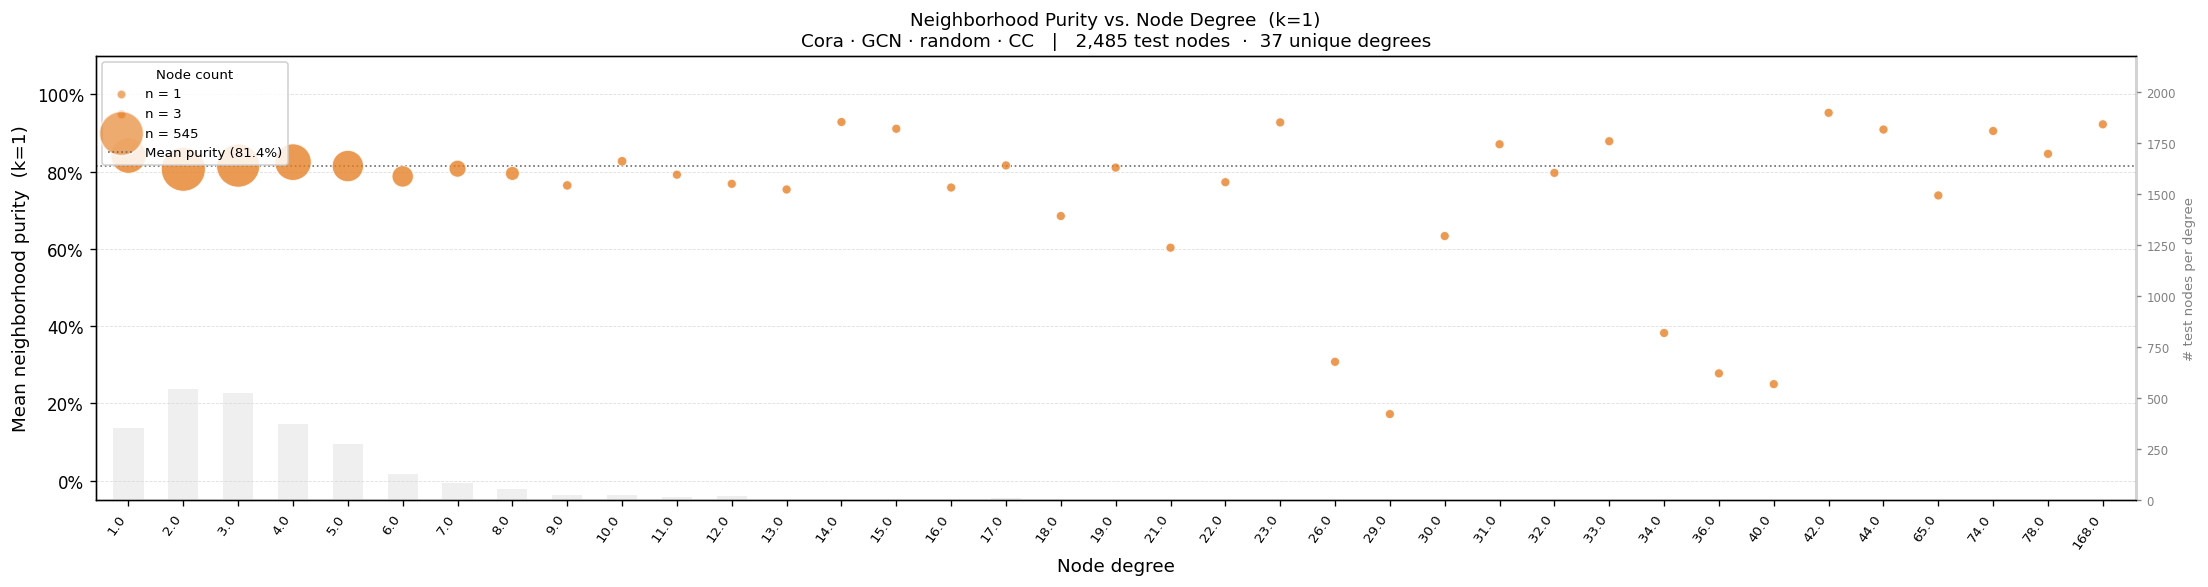

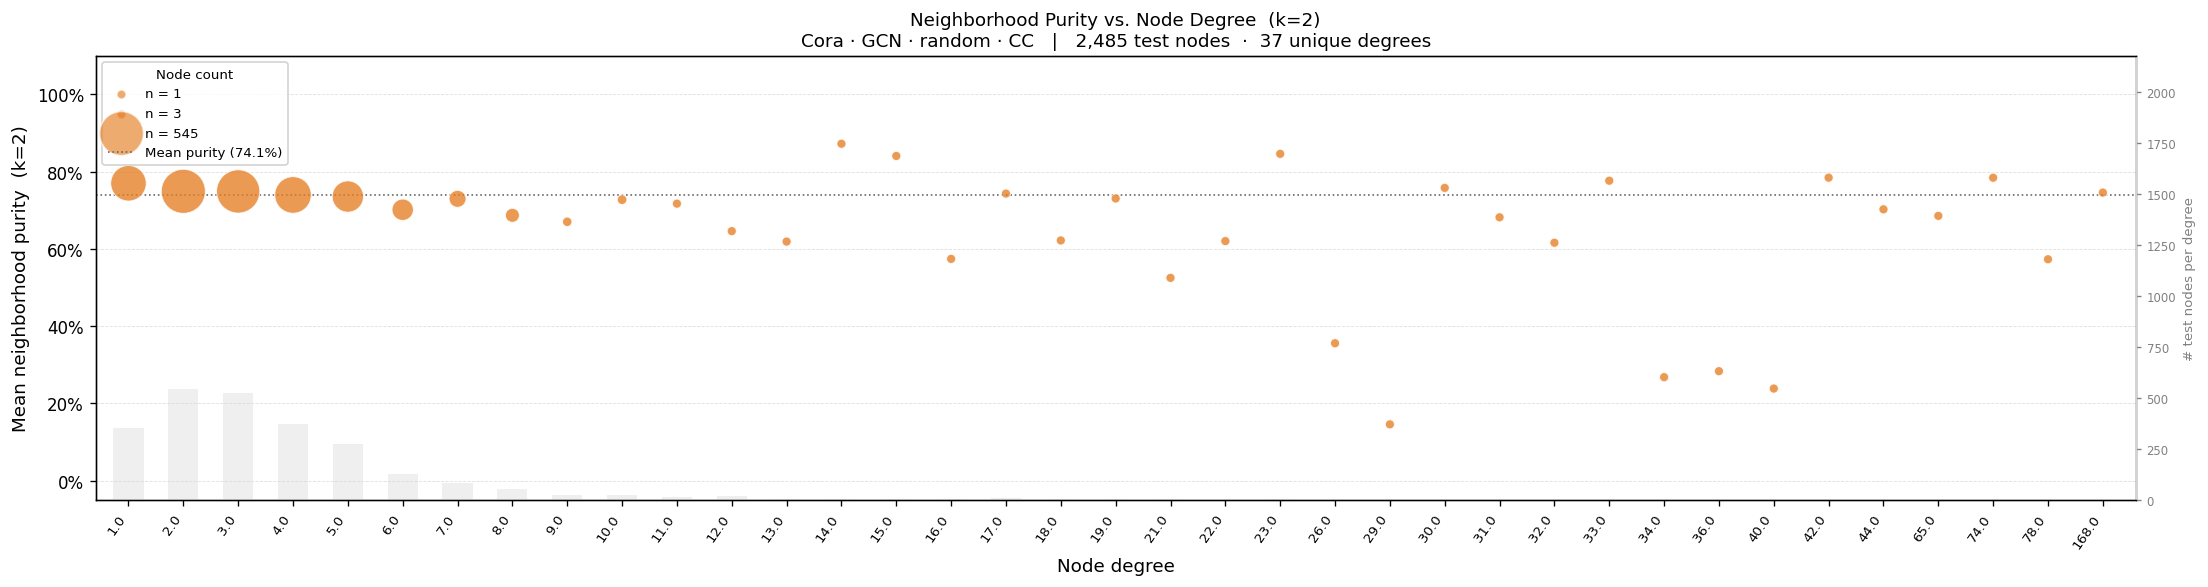

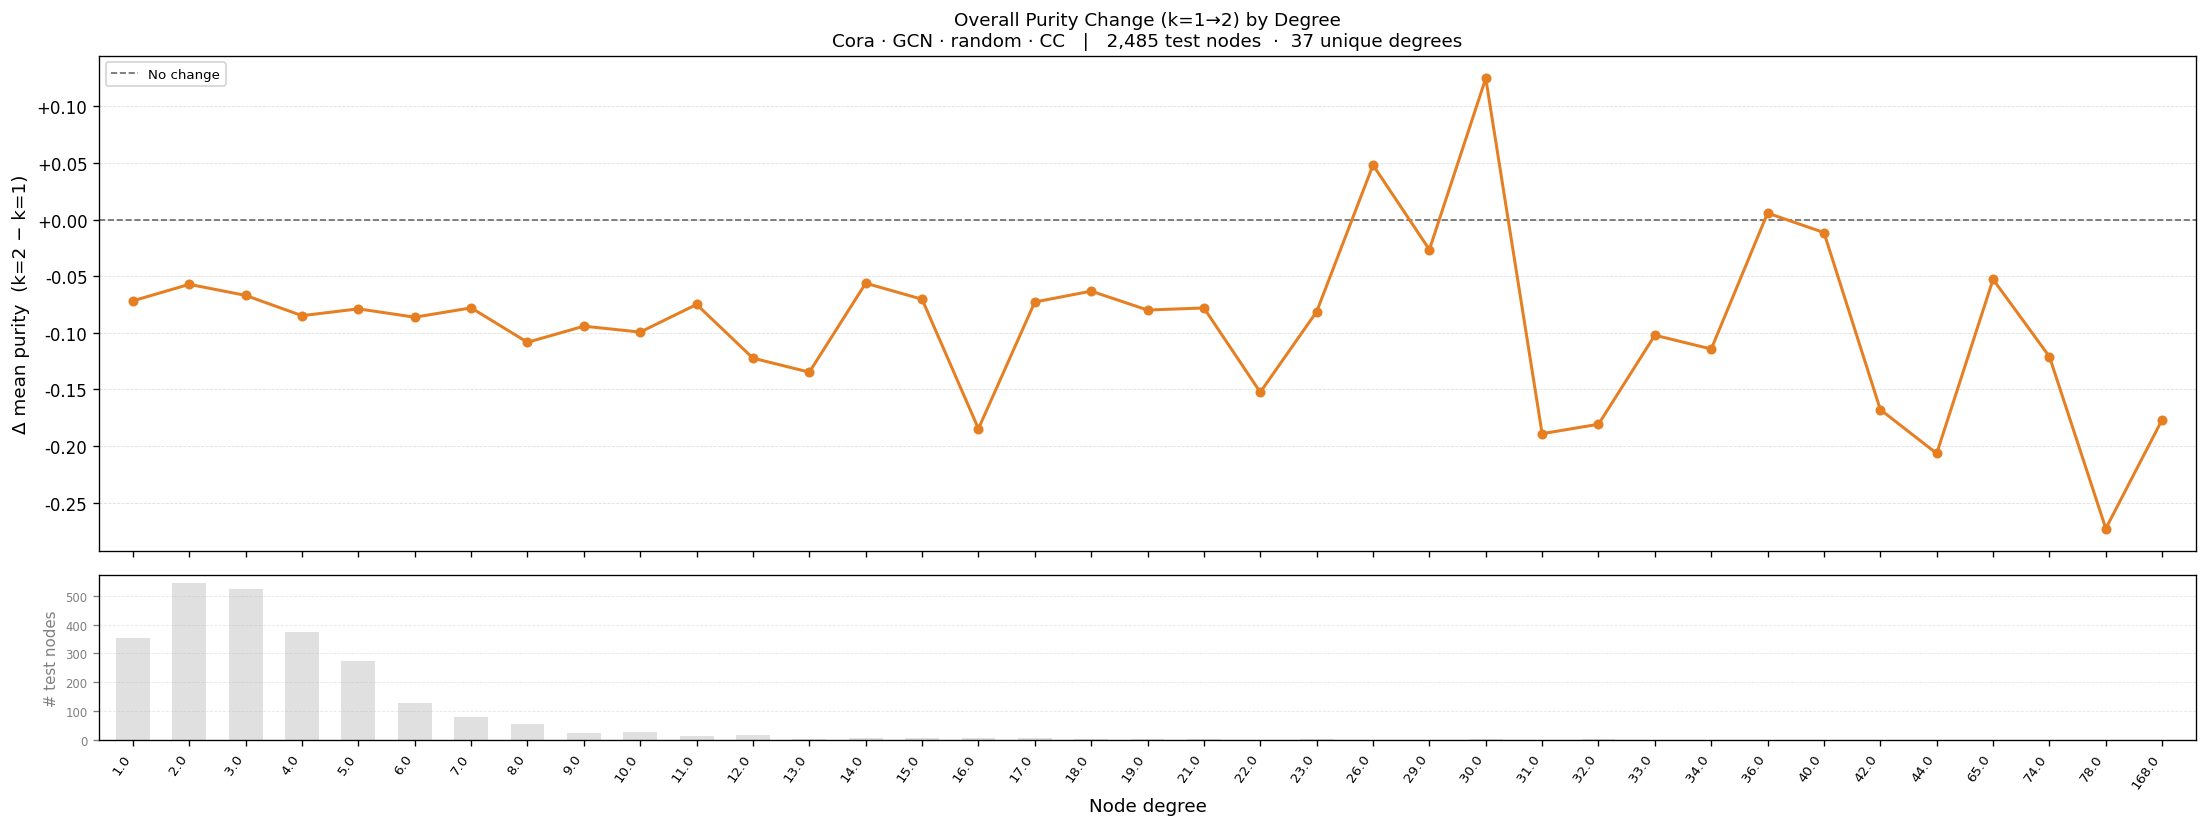

In [10]:
from plot_utils import plot_purity_vs_degree, plot_purity_delta_by_degree

# Purity at each k value
for k, purity_all in purity_by_k.items():
    plot_purity_vs_degree(
        all_deg, purity_all, cfg, k,
        save_dir=None, show=True,
    )

# Delta purity: purity(k_max) - purity(k_min) per degree group
if len(purity_by_k) > 1:
    plot_purity_delta_by_degree(
        all_deg, purity_by_k, cfg,
        save_dir=None, show=True,
    )


---
### 4.8 Training-Neighbor Degree Distribution

**Why this matters:**
In GCN, the aggregation weight for edge $(u \to v)$ is:

$$w_{uv} = \frac{1}{\sqrt{\deg(u) \cdot \deg(v)}}$$

This means **higher-degree training nodes contribute less per edge** than lower-degree ones. A same-class training node with degree 20 has a weaker per-edge contribution than one with degree 2, even if both are at the same hop distance.

The count of same-class vs diff-class training nodes (which drives the SPL and labelling ratio analysis) tells us *how many* training nodes of each type are reachable. This metric instead asks: **how strongly does each group contribute per edge, given the GCN normalisation?**

If diff-class training nodes in a test node's neighbourhood tend to have **lower degree** than same-class training nodes, their per-edge signal is proportionally *stronger*. Even if there are fewer diff-class training nodes, they may dominate the aggregated message because of the degree normalisation.

The **degree advantage** (same_mean_deg − diff_mean_deg) splits correctly classified vs misclassified nodes to test whether anomalously misclassified nodes show a consistent pattern: diff-class training nodes with systematically lower degree (stronger per-edge contribution) than same-class ones.


In [ ]:
from plot_utils import plot_train_neighbor_degree_stats

plot_train_neighbor_degree_stats(
    train_nb_deg_stats, test_deg, final_pred, data, cfg,
    k=k_hops,
    save_dir=None, show=True,
)


---
### 4.9 Influence Analysis

**Why this matters:**
All preceding metrics describe **structural properties of the graph** — they characterise what the *input signal* to the GNN looks like for each node. But they do not tell us what the **trained model** actually does with that signal.

The influence analysis asks directly: which nodes' input features does the trained model actually use when forming its prediction for a target node?

The exact influence distribution (Definition 3.1) is computed via Jacobian:

$$I(x, y) = \sum_{i,f} \left|\frac{\partial h_x^{(k)}[i]}{\partial h_y^{(0)}[f]}\right|, \quad I_x(y) = \frac{I(x,y)}{\sum_z I(x,z)}$$

where $h_x^{(k)}$ is the final-layer embedding of node $x$ and $h_y^{(0)}$ is the input feature vector of node $y$.

The training nodes within the k-hop receptive field are split into **same-class** and **diff-class** groups. Their normalised influence scores (normalised by total training-node influence so they sum to 1 between the two groups) reveal whether the trained model routes more of its effective signal from same-class or diff-class training nodes.

**Key finding for node 1362 (degree 22, GCN 2-layer):** with `same_train=4` and `diff_train=11` training nodes in the 2-hop field, the model routes `same_class_influence ≈ 0` and `diff_class_influence ≈ 1.0`. Despite 4 same-class training nodes being structurally present, the trained model has converged to essentially ignore them — a direct demonstration that the structural imbalance (11 vs 4) is *amplified*, not corrected, by the model's learned weights.

> **Note:** The influence analysis requires computing an exact Jacobian over the full graph, which is memory-intensive. Set `influence_degrees` below to the specific degree values you want to investigate.


In [ ]:
from influence import compute_influence_analysis
from plot_utils import plot_influence_analysis, plot_influence_per_neighbor

# Set the exact degree values to investigate.
# The analysis selects one test node per degree (preferring misclassified ones).
# Example: [3, 10, 22]  — leave empty [] to skip.
influence_degrees = cfg['plot'].get('influence_degrees', [])

if influence_degrees:
    print(f'Running influence analysis for degrees: {influence_degrees}')
    influence_results = compute_influence_analysis(
        final_model, data, final_pred,
        k_hops=k_hops,
        target_degrees=influence_degrees,
    )

    # Aggregate bar plot: normalised same vs diff class influence per selected node
    plot_influence_analysis(
        influence_results, cfg,
        save_dir=None, show=True,
    )

    # Per-neighbor breakdown: one bar per training node in the receptive field
    plot_influence_per_neighbor(
        influence_results, cfg,
        save_dir=None, show=True,
    )
else:
    print('influence_degrees is empty — set it in config.yaml or override here.')
    print('Example: influence_degrees = [3, 10, 22]')
    print('Then re-run this cell.')


---
## 5. Key Observations

> Based on GCN (2 layers, hidden dim 512) on Cora, 5 seeds, random split.

### 5.1 Accuracy vs degree: a general trend with anomalous exceptions

The general relationship is that **higher-degree nodes achieve higher median accuracy** — more connections provide richer aggregated signal. Low-degree nodes (degree 1–2) are highly variable: their single or few neighbours determine almost entirely whether same-class signal is available. Mid-to-high degree nodes are more stable across runs.

**The central finding is the anomaly:** specific mid- and high-degree nodes are persistently misclassified despite the general advantage of higher connectivity. These anomalies would be masked by coarse degree binning — they only appear with granular, per-degree-value analysis. Understanding what distinguishes these nodes is the core motivation for every subsequent metric.

### 5.2 K-hop degree: extended connectivity matters

The relationship with 2-hop degree is smoother and stronger than with 1-hop degree. Nodes in densely connected regions (large 2-hop neighbourhood) tend to be classified more reliably, consistent with the GNN being able to draw on richer information even with few direct neighbours.

### 5.3 Distance to training nodes: same-class distance is the telling metric

`dist_to_train` is short for most test nodes — high-degree nodes especially. But `dist_to_same_class_train` is more variable: even nodes close to some training node can be far from a same-class one. High-degree test nodes that are 3+ hops from the nearest same-class training node tend to be anomalously misclassified.

### 5.4 Average SPL: same-class signal coverage

Nodes with high average SPL to same-class training nodes receive class-specific label signal from a structurally remote part of the graph — multiple hops of mixing before it arrives. This compounds with neighbourhood purity: the signal is both diluted and noisy by the time it reaches the target node.

### 5.5 Labelling ratio: first-hop label access matters

Having a directly labelled (training) neighbour is a meaningful advantage. The fraction of test nodes with at least one such neighbour co-varies with accuracy across degree groups. Nodes without any labelled direct neighbour must rely on indirect signal that has already been averaged through non-training intermediaries.

### 5.6 Neighbourhood purity: degree-heterogeneity co-occurs with misclassification

Purity decreases with degree: high-degree nodes have more heterogeneous neighbourhoods by construction (Cora's hub nodes span multiple research communities). Delta purity is negative and steeper for high-degree nodes — the neighbourhood quality degrades faster as the GNN's receptive field expands. For most high-degree nodes, richer aggregation still wins. For the anomalous cases, the noise tips the balance.

### 5.7 Training-neighbor degree: aggregation weighting can amplify imbalance

The GCN normalisation factor $1/\sqrt{\deg(u) \cdot \deg(v)}$ means low-degree training nodes contribute *more strongly per edge* than high-degree ones. If diff-class training nodes in a test node's neighbourhood happen to have lower degree than same-class ones, their per-edge signal is proportionally stronger despite being the wrong class — an additional compounding factor beyond raw count imbalance.

### 5.8 Influence analysis: the model amplifies structural bias

For node 1362 (degree 22, 2-hop field contains 4 same-class and 11 diff-class training nodes):
- `same_class_influence_norm ≈ 0.0`
- `diff_class_influence_norm ≈ 1.0`

The trained model routes essentially **zero influence** from the 4 structurally-present same-class training nodes. The combination of degree-normalised aggregation dilution, dead ReLU paths, and potentially learned weight suppression results in the model treating diff-class signal as the primary input for this node's prediction. This is causal model-behaviour evidence — not just a structural observation — that the aggregation failure for specific high-degree nodes is real and systematic.

### 5.9 The emerging story: a compounding cascade

The anomalous misclassifications are not explained by any single factor but by the compounding of four:
1. **Neighbourhood class imbalance (structural)** — more diff-class training nodes in the receptive field
2. **Degree-normalised aggregation dilution (architectural)** — no mechanism to upweight same-class signal
3. **Learned weight suppression (optimisation)** — the model converges to essentially ignoring same-class training nodes for these specific inputs
4. **Propagation dilution (depth)** — same-class signal travels through more intermediate nodes before reaching the target

Most high-degree nodes avoid this fate because their neighbourhood composition is more favourable. The anomalies are the unlucky intersection of all four compounding factors.


---
## 6. Open Questions & Future Work

The current analysis establishes the structural narrative and confirms it with a single model-behaviour data point (node 1362). To move from *motivated hypothesis* to *demonstrated general phenomenon*, the following investigations are open:

### 6.1 Cardinality analysis (same vs diff class count)

**Question:** Does `same_count > diff_count` in the k-hop neighbourhood reliably predict correct classification across all test nodes and seeds?

**Approach:**
- Compute the "class advantage ratio" = `same_count / (same_count + diff_count)` for all test nodes
- Plot accuracy vs class advantage ratio; group by degree
- Check consistency across 5 seeds: is a node with same-class majority always classified correctly?

*(See `TODO.md §1` for full description)*

### 6.2 Mean feature distance as neighbourhood noise metric

**Question:** Does the mean L2/cosine distance between a test node's features and its neighbours' features correlate with accuracy? Feature-space outliers receive misleading aggregated signal even if their structural neighbourhood is favourable.

**Approach:**
- Compute `mean_feat_dist`, `mean_feat_dist_same`, `mean_feat_dist_diff` per test node
- Plot against degree and against classification accuracy

*(See `TODO.md §2` for full description)*

### 6.3 Hidden dimension sweep

**Question:** Does GCN's hidden dimension interact with degree bias? Does larger capacity allow the model to recover more same-class influence for anomalous high-degree nodes?

**Approach:**
- Sweep hidden dims [16, 32, 64, 128, 256, 512]
- For each, record accuracy vs degree and same_class_influence for selected anomalous nodes

*(See `TODO.md §3` for full description)*

### 6.4 Broader validation

- **Across seeds:** are the same high-degree test nodes consistently misclassified, or does it vary with model initialisation?
- **Across splits:** do anomalous misclassifications persist under different random splits (different training node placements)?
- **Across datasets:** CiteSeer, PubMed, ogbn-arxiv; heterophilic graphs (Chameleon, Squirrel) where more connections do not imply noisier class signal
- **Across models:** GCN vs GCNII vs GAT — does attention help high-degree nodes recover same-class signal?

### 6.5 Higher-hop influence analysis

Run the influence analysis for the same selected anomalous nodes at k=3 and k=4 layers:
- **GCN hypothesis:** same-class influence stays near zero or decreases further (over-smoothing + purity degradation compounding)
- **GCNII hypothesis:** initial residual preserves some same-class signal even at greater depth, providing a contrastive baseline

If GCNII shows higher same-class influence at k=4 than GCN does at k=2, that isolates the architectural choice — not just the structural neighbourhood — as a determining factor in whether the model can recover the same-class signal that is structurally present.

### 6.6 Causal intervention experiments

The current analysis is observational. To establish that structural neighbourhood imbalance *causes* misclassification (rather than merely correlates), intervention experiments are needed:
- Manually upweight same-class gradients during training — does misclassification of anomalous nodes decrease?
- Mask out diff-class training nodes from the receptive field — does the model classify correctly?
- These are not currently implemented; they represent the next step in moving from correlation to causation.

---

*For ongoing Q&A on metrics, plots, and model behaviour, see `NOTES.md`. For full descriptions of pending implementations, see `TODO.md`. For the full research narrative, see `RESEARCH.md`.*
